# DNN Rainfall Prediction with Enhancements

This notebook tackles the Rainfall Prediction challenge using a deep neural network.  
It includes:
1. Exploratory Data Analysis (EDA)
2. Advanced Feature Engineering
3. Cross-Validation for robust evaluation
4. Training metrics visualization
5. Hyperparameter tuning with Optuna and visual study insights
6. Calibration curve visualization for probability calibration

Let's get started!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.calibration import calibration_curve, CalibrationDisplay
import optuna

# For reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Load data
train_df = pd.read_csv("/kaggle/input/playground-series-s5e3/train.csv")
test_df = pd.read_csv("/kaggle/input/playground-series-s5e3/test.csv")
sample_submission = pd.read_csv("/kaggle/input/playground-series-s5e3/sample_submission.csv")

# Handle missing values in test set
test_df.fillna(train_df.median(), inplace=True)


## 1. Exploratory Data Analysis (EDA)

Let's take a look at the distribution of our features and the target variable. We will plot some histograms and a correlation heatmap.


                id          day     pressure      maxtemp  temparature  \
count  2190.000000  2190.000000  2190.000000  2190.000000  2190.000000   
mean   1094.500000   179.948402  1013.602146    26.365799    23.953059   
std     632.342866   105.203592     5.655366     5.654330     5.222410   
min       0.000000     1.000000   999.000000    10.400000     7.400000   
25%     547.250000    89.000000  1008.600000    21.300000    19.300000   
50%    1094.500000   178.500000  1013.000000    27.800000    25.500000   
75%    1641.750000   270.000000  1017.775000    31.200000    28.400000   
max    2189.000000   365.000000  1034.600000    36.000000    31.500000   

           mintemp     dewpoint     humidity        cloud     sunshine  \
count  2190.000000  2190.000000  2190.000000  2190.000000  2190.000000   
mean     22.170091    20.454566    82.036530    75.721918     3.744429   
std       5.059120     5.288406     7.800654    18.026498     3.626327   
min       4.000000    -0.300000    39

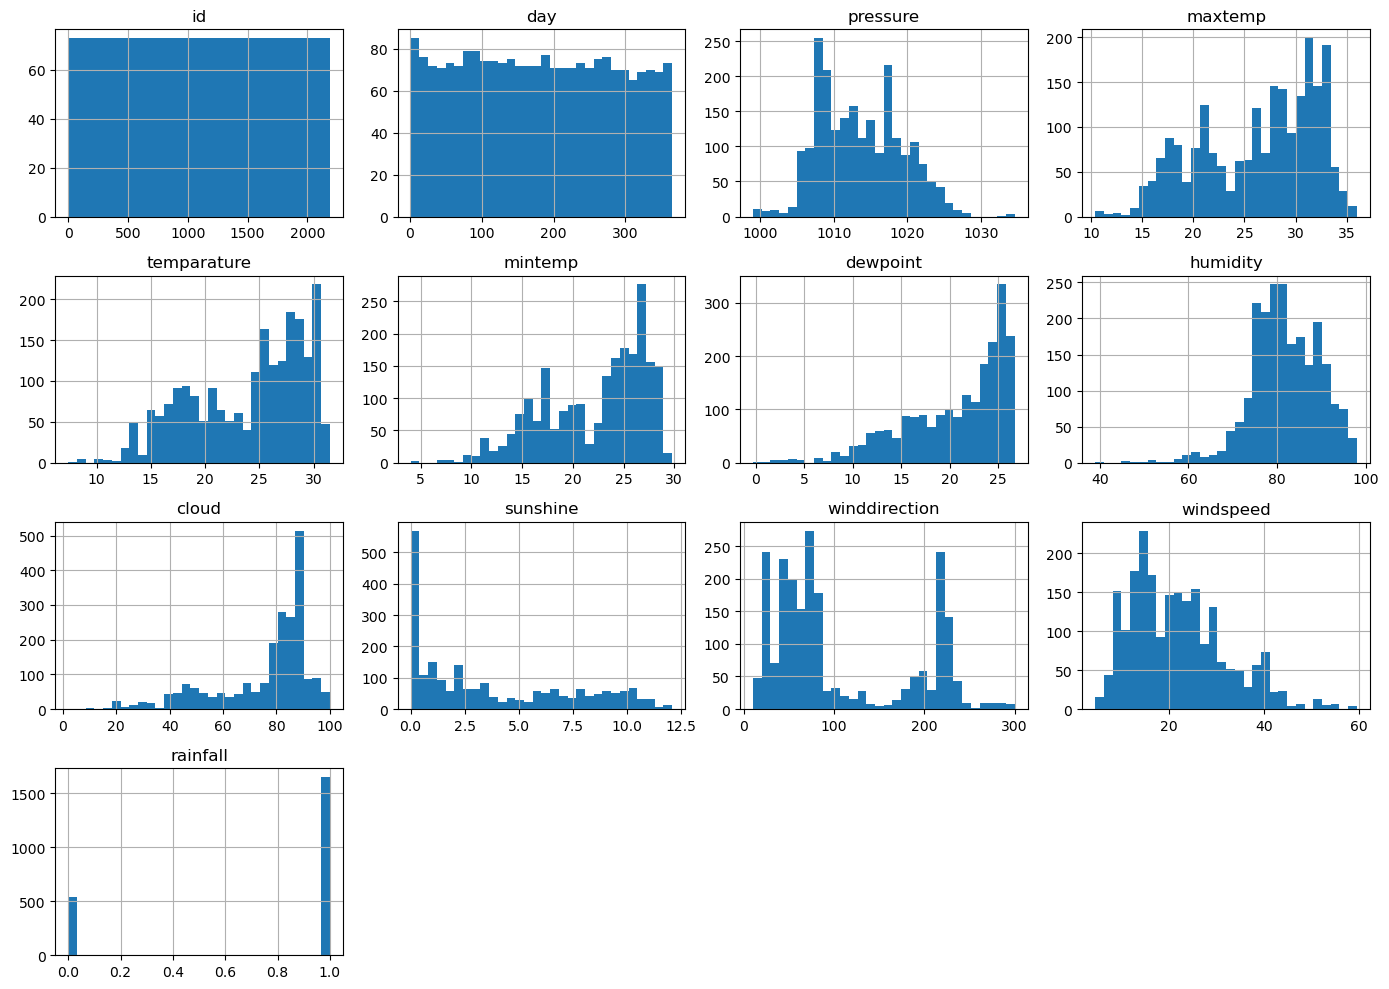

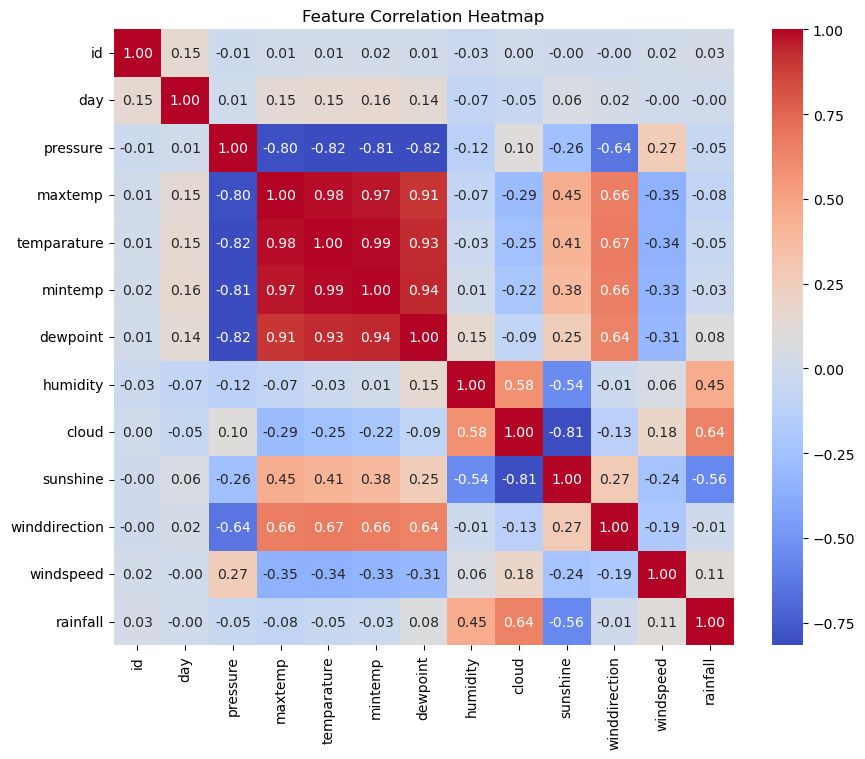

In [5]:
# Display basic statistics
print(train_df.describe())

# Plot histograms for numerical features
train_df.hist(bins=30, figsize=(14,10))
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


## 2. Advanced Feature Engineering

rempoing "mintemp","maxtemp" because they are similare to temparature and dewpoint

In [7]:
X_train_features = train_df.drop(columns=["id", "rainfall","mintemp","maxtemp"], errors='ignore')
X_test_features = test_df.drop(columns=["id","mintemp","maxtemp"], errors='ignore')
y_train = train_df["rainfall"]

## 3. Preprocessing and Class Weights

We scale our features using StandardScaler.  
We also define class weights: class 0 is weighted 6 times more than class 1.


In [9]:
# Define class weights: 0 weighted 3.5 times more than 1
class_weights = {0: 3.5, 1: 1}

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)


## 4. Cross-Validation

We can assess our model's stability with K-Fold cross-validation.  
Here, we define a function to build the model (for use in cross-validation) and then compute the average AUC over folds.


In [11]:
# !pip install scikeras

In [12]:
from scikeras.wrappers import KerasClassifier

def build_model(units1, units2, units3, units4, dropout1, dropout2, dropout3, lr):
    model = keras.Sequential([
        keras.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(units1, activation='swish'),
        layers.BatchNormalization(),
        layers.Dropout(dropout1),
        layers.Dense(units2, activation='swish'),
        layers.BatchNormalization(),
        layers.Dropout(dropout2),
        layers.Dense(units3, activation='swish'),
        layers.BatchNormalization(),
        layers.Dropout(dropout3),
        layers.Dense(units4, activation='swish'),
        layers.BatchNormalization(),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc')])
    return model

# Example cross-validation with fixed hyperparameters (for illustration)
from sklearn.model_selection import cross_val_score

# Wrap the model so that it can be used by scikit-learn
def create_model_cv():
    return build_model(2048,1024, 512, 256,0.5, 0.4, 0.3, 1e-4)

cv_model = KerasClassifier(model=create_model_cv, epochs=25, batch_size=128, verbose=0)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(cv_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
print(f"Average CV AUC: {np.mean(cv_scores):.4f}")


Average CV AUC: 0.8683


## 5. Hyperparameter Tuning with Optuna

We now use Optuna to search for the best hyperparameters that maximize validation AUC.


In [14]:
def objective(trial):
    units1 = trial.suggest_int('units1', 512, 2048, step=512)
    units2 = trial.suggest_int('units2', 256, 1024, step=256)
    units3 = trial.suggest_int('units3', 128, 512, step=128)
    units4 = trial.suggest_int('units4', 64, 128, step=32)
    dropout1 = trial.suggest_float('dropout1', 0.3, 0.5)
    dropout2 = trial.suggest_float('dropout2', 0.2, 0.4)
    dropout3 = trial.suggest_float('dropout3', 0.3, 0.4)
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)

    model = keras.Sequential([
        keras.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(units1, activation='swish'),
        layers.BatchNormalization(),
        layers.Dropout(dropout1),
        layers.Dense(units2, activation='swish'),
        layers.BatchNormalization(),
        layers.Dropout(dropout2),
        layers.Dense(units3, activation='swish'),
        layers.BatchNormalization(),
        layers.Dropout(dropout3),
        layers.Dense(units4, activation='swish'),
        layers.BatchNormalization(),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc')])

    history = model.fit(X_train_scaled, y_train,
                        validation_split=0.2,
                        epochs=25,
                        batch_size=128,
                        verbose=0,
                        class_weight=class_weights)
    return max(history.history['val_auc'])

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
best_params = study.best_params
print("Best hyperparameters:", best_params)


[I 2025-03-15 03:28:53,752] A new study created in memory with name: no-name-0aaefd85-d225-4eae-8bbc-5ca867b1646c
[I 2025-03-15 03:29:21,223] Trial 0 finished with value: 0.8866863250732422 and parameters: {'units1': 1536, 'units2': 1024, 'units3': 384, 'units4': 96, 'dropout1': 0.3320947091508342, 'dropout2': 0.35684457528122526, 'dropout3': 0.31838197829401094, 'lr': 0.00018289886806997042}. Best is trial 0 with value: 0.8866863250732422.
[I 2025-03-15 03:29:37,481] Trial 1 finished with value: 0.8874089121818542 and parameters: {'units1': 2048, 'units2': 256, 'units3': 384, 'units4': 64, 'dropout1': 0.4984686431935636, 'dropout2': 0.20499217095969077, 'dropout3': 0.31125638925739857, 'lr': 5.6353340864281124e-05}. Best is trial 1 with value: 0.8874089121818542.
[I 2025-03-15 03:29:56,075] Trial 2 finished with value: 0.8879115581512451 and parameters: {'units1': 1536, 'units2': 512, 'units3': 128, 'units4': 64, 'dropout1': 0.4765801941771241, 'dropout2': 0.38120610866359833, 'dropou

Best hyperparameters: {'units1': 1536, 'units2': 1024, 'units3': 128, 'units4': 128, 'dropout1': 0.32245991854253675, 'dropout2': 0.3491677682521164, 'dropout3': 0.3884027535861917, 'lr': 3.076113371119375e-05}


## 6. Final Model Training

We build the final model using the best hyperparameters from Optuna.  
Callbacks (ReduceLROnPlateau & EarlyStopping) help improve convergence and avoid overfitting.


In [16]:
model = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(best_params['units1'], activation='swish'),
    layers.BatchNormalization(),
    layers.Dropout(best_params['dropout1']),
    layers.Dense(best_params['units2'], activation='swish'),
    layers.BatchNormalization(),
    layers.Dropout(best_params['dropout2']),
    layers.Dense(best_params['units3'], activation='swish'),
    layers.BatchNormalization(),
    layers.Dropout(best_params['dropout3']),
    layers.Dense(best_params['units4'], activation='swish'),
    layers.BatchNormalization(),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=best_params['lr']),
              loss='binary_crossentropy',
              metrics=[keras.metrics.AUC(name='auc')])

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

history = model.fit(X_train_scaled, y_train,
                    validation_split=0.2,
                    epochs=200,
                    batch_size=128,
                    verbose=1,
                    class_weight=class_weights,
                    callbacks=[reduce_lr, early_stopping])


Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - auc: 0.5610 - loss: 1.3864 - val_auc: 0.8829 - val_loss: 0.6994 - learning_rate: 3.0761e-05
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - auc: 0.8323 - loss: 0.8583 - val_auc: 0.8819 - val_loss: 0.7033 - learning_rate: 3.0761e-05
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - auc: 0.8609 - loss: 0.7983 - val_auc: 0.8811 - val_loss: 0.7072 - learning_rate: 3.0761e-05
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - auc: 0.8749 - loss: 0.7696 - val_auc: 0.8836 - val_loss: 0.7115 - learning_rate: 3.0761e-05
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - auc: 0.8774 - loss: 0.7610 - val_auc: 0.8793 - val_loss: 0.7136 - learning_rate: 3.0761e-05
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - auc: 0.8810 - loss: 0.7482 - val_auc: 0.8808 - val_loss: 0.7132 - learning_rate: 3.0761e-05
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - auc: 0.8853 - loss: 0.7304 - val_auc: 0.8801 - val_loss: 0.7109 - lear

## 7. Training Visualization

Let's visualize the training and validation loss and AUC curves over epochs.


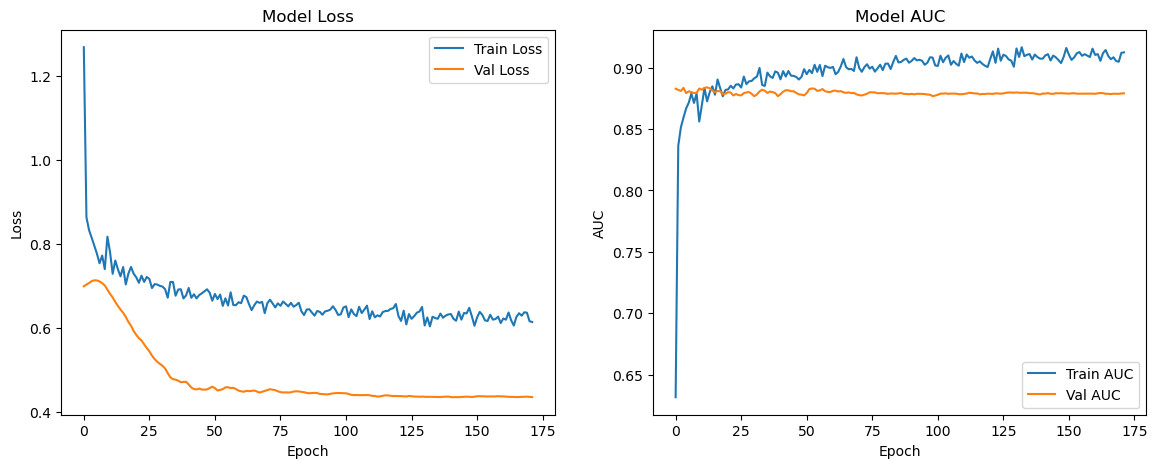

In [18]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.show()


## 8. Calibration Curve Visualization

We can check if our predicted probabilities are well calibrated by plotting a calibration curve.


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step   


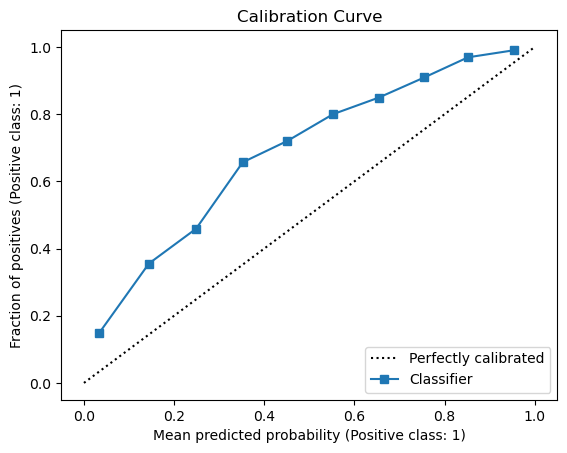

In [20]:
# Get predicted probabilities on the validation set (using the validation split from final training)
# Here we use the final model to predict on the validation part from the train split.
# In a real scenario, you might want to set aside a dedicated calibration set.
from sklearn.calibration import CalibrationDisplay

# Get predicted probabilities on the validation set
val_preds = model.predict(X_train_scaled).flatten()  # Or use your validation set predictions

# Create a calibration curve display using the true labels and predicted probabilities
disp = CalibrationDisplay.from_predictions(y_train, val_preds, n_bins=10)
plt.title("Calibration Curve")
plt.show()



## 9. Generating Predictions and Saving Submission

Finally, we generate predictions on the test set and save the results in the required format for Kaggle.


In [22]:
predictions = model.predict(X_test_scaled).flatten()
sample_submission["rainfall"] = predictions
sample_submission.to_csv("submission.csv", index=False)
print("Predictions saved to submission.csv")


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Predictions saved to submission.csv
